In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [23]:
import os
print(os.listdir())

['.gitkeep', '.ipynb_checkpoints', 'data_understanding.ipynb', 'SkillScope_AI_EDA.ipynb', 'Skill_Extraction.ipynb']


In [24]:
import os

print(os.getcwd())

M:\SkillScope-AI\notebooks


In [25]:
df = pd.read_csv("../data/featured_jobs.csv")

df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,min_salary,max_salary,average_salary
0,"Data Analyst, Center on Immigration and Justic...",37-66,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),NaN,True,37.0,66.0,51.5
1,Quality Data Analyst,37-66,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),NaN,NaN,37.0,66.0,51.5
2,"Senior Data Analyst, Insights & Analytics Team...",37-66,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,NaN,37.0,66.0,51.5
3,Data Analyst,37-66,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),NaN,NaN,37.0,66.0,51.5
4,Reporting Data Analyst,37-66,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37.0,66.0,51.5


In [26]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply', 'min_salary', 'max_salary', 'average_salary'],
      dtype='object')

In [27]:
print(df.shape)

print(df.columns)

df.info()

df.describe()

(2253, 18)
Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply', 'min_salary', 'max_salary', 'average_salary'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2253 non-null   object 
 1   Salary Estimate    2252 non-null   object 
 2   Job Description    2253 non-null   object 
 3   Rating             2253 non-null   float64
 4   Company Name       2252 non-null   object 
 5   Location           2253 non-null   object 
 6   Headquarters       2081 non-null   object 
 7   Size               2090 non-null   object 
 8   Founded            2253 non-null   int64  
 9   Type of ownership  2090 non-null   object 
 1

,Rating,Founded,min_salary,max_salary,average_salary
count,2253.000000,2253.000000,2252.000000,2252.000000,2252.000000
mean,3.160630,1398.522858,54.266874,89.979130,72.123002
std,1.665228,901.929251,19.575375,29.315605,23.600734
min,-1.000000,-1.000000,24.000000,38.000000,33.500000
25%,3.100000,-1.000000,41.000000,70.000000,58.000000
50%,3.600000,1979.000000,50.000000,87.000000,69.000000
75%,4.000000,2002.000000,64.000000,104.000000,80.500000
max,5.000000,2019.000000,113.000000,190.000000,150.000000


In [28]:
df.isnull().sum().sort_values(ascending=False)

Easy Apply           2173
Competitors          1732
Industry              353
Sector                353
Headquarters          172
Size                  163
Type of ownership     163
Revenue               163
Company Name            1
Salary Estimate         1
max_salary              1
min_salary              1
average_salary          1
Job Title               0
Founded                 0
Job Description         0
Rating                  0
Location                0
dtype: int64

In [29]:
df = df.dropna(subset=['average_salary'])

In [30]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['job_title', 'salary_estimate', 'job_description', 'rating',
       'company_name', 'location', 'headquarters', 'size', 'founded',
       'type_of_ownership', 'industry', 'sector', 'revenue', 'competitors',
       'easy_apply', 'min_salary', 'max_salary', 'average_salary'],
      dtype='object')


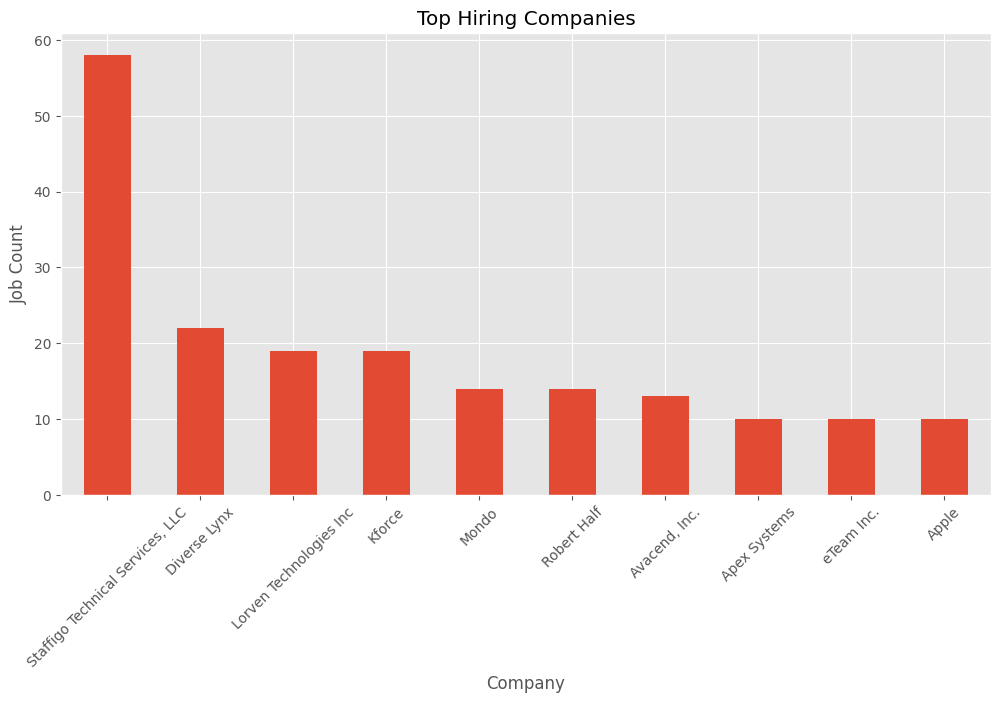

In [31]:
top_companies = df['company_name'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_companies.plot(kind='bar')

plt.title("Top Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Job Count")

plt.xticks(rotation=45)

plt.show()

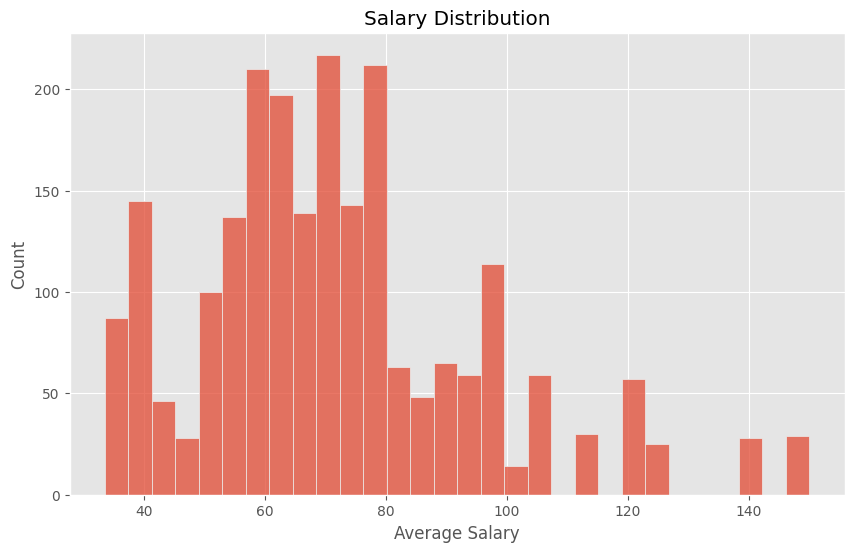

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(df['average_salary'], bins=30)

plt.title("Salary Distribution")
plt.xlabel("Average Salary")

plt.show()

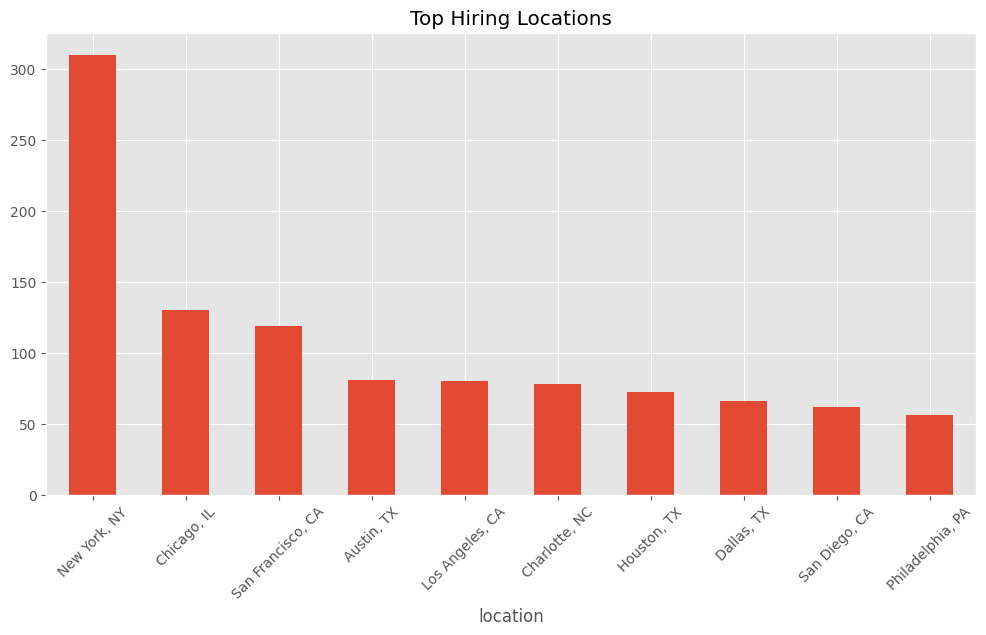

In [33]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_locations.plot(kind='bar')

plt.title("Top Hiring Locations")

plt.xticks(rotation=45)

plt.show()

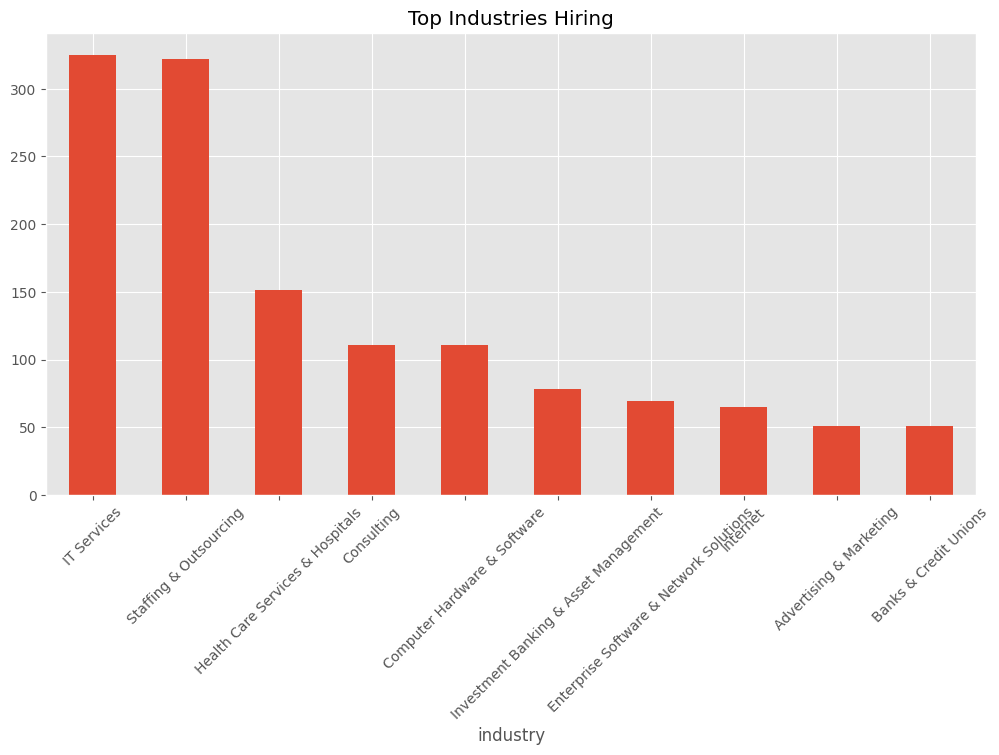

In [34]:
top_industries = df['industry'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_industries.plot(kind='bar')

plt.title("Top Industries Hiring")

plt.xticks(rotation=45)

plt.show()

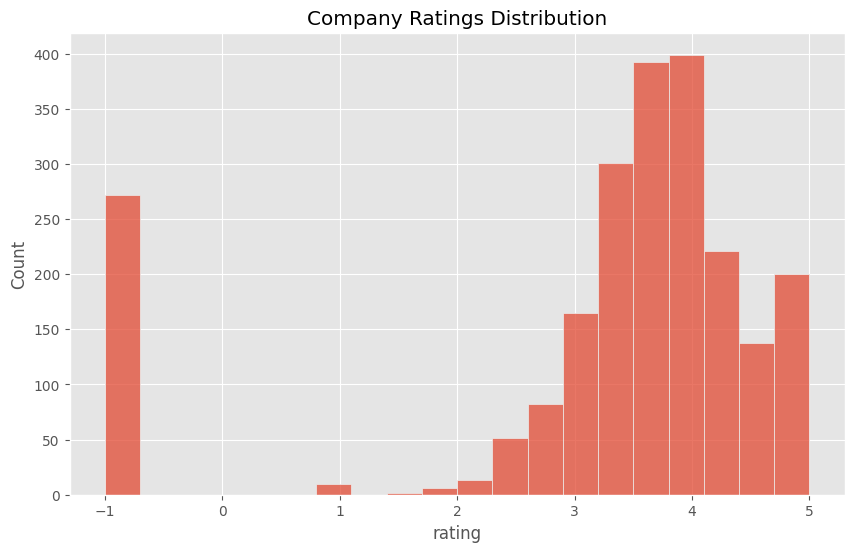

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(df['rating'], bins=20)

plt.title("Company Ratings Distribution")

plt.show()

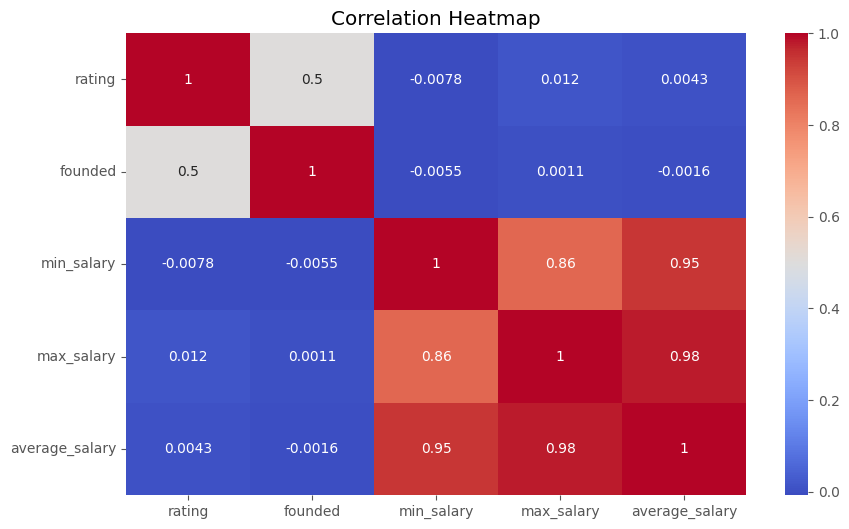

In [36]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

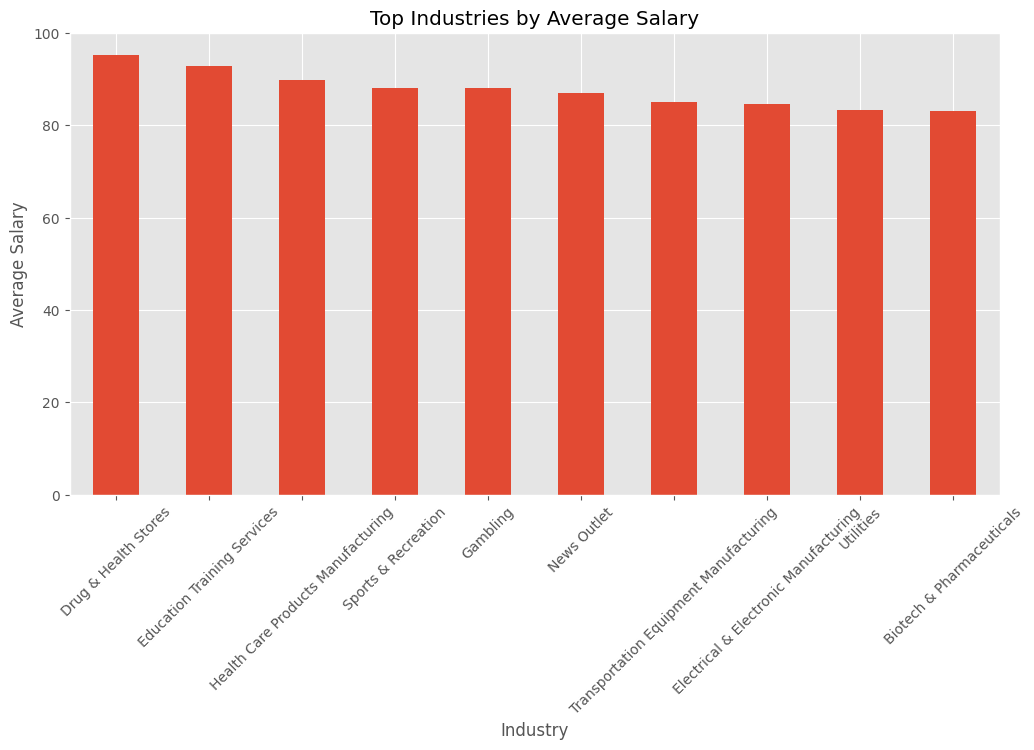

In [37]:
industry_salary = df.groupby('industry')['average_salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

industry_salary.plot(kind='bar')

plt.title("Top Industries by Average Salary")
plt.xlabel("Industry")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

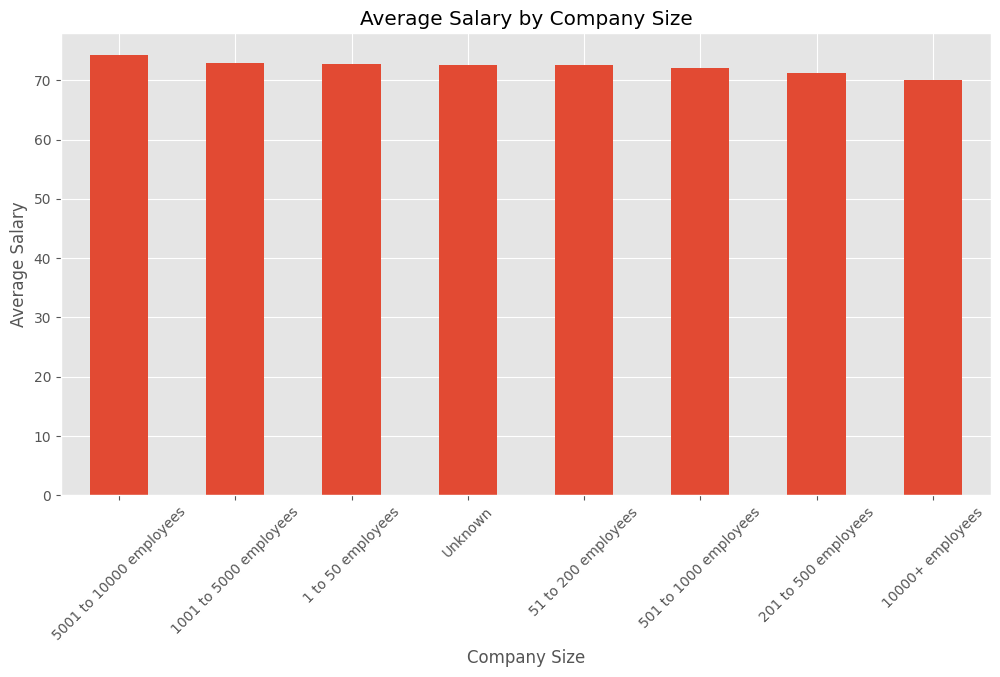

In [38]:
size_salary = df.groupby('size')['average_salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

size_salary.plot(kind='bar')

plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

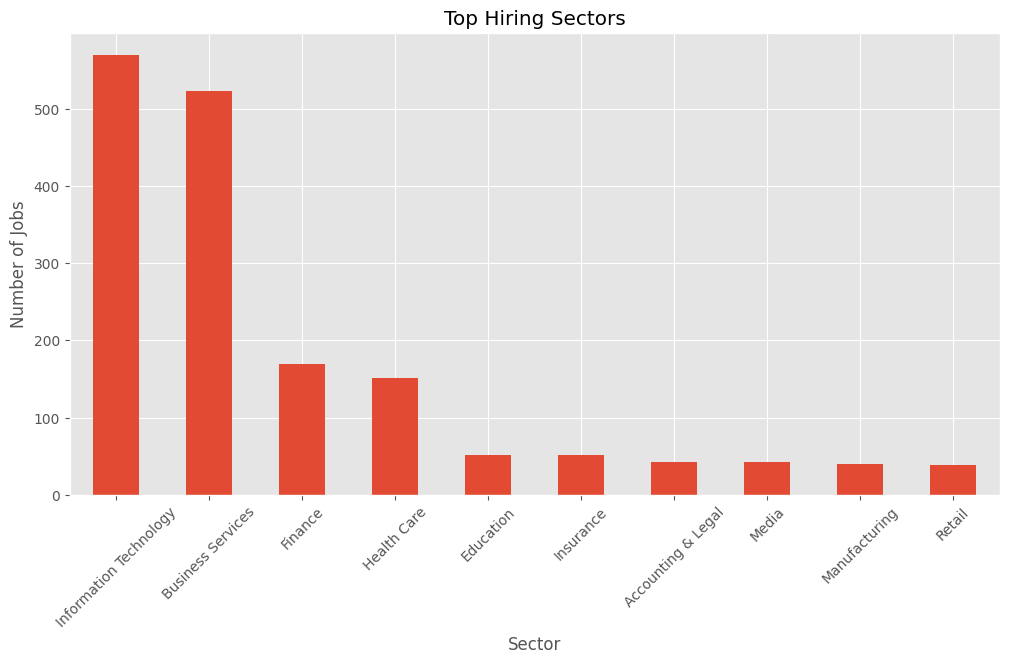

In [39]:
top_sectors = df['sector'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_sectors.plot(kind='bar')

plt.title("Top Hiring Sectors")
plt.xlabel("Sector")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

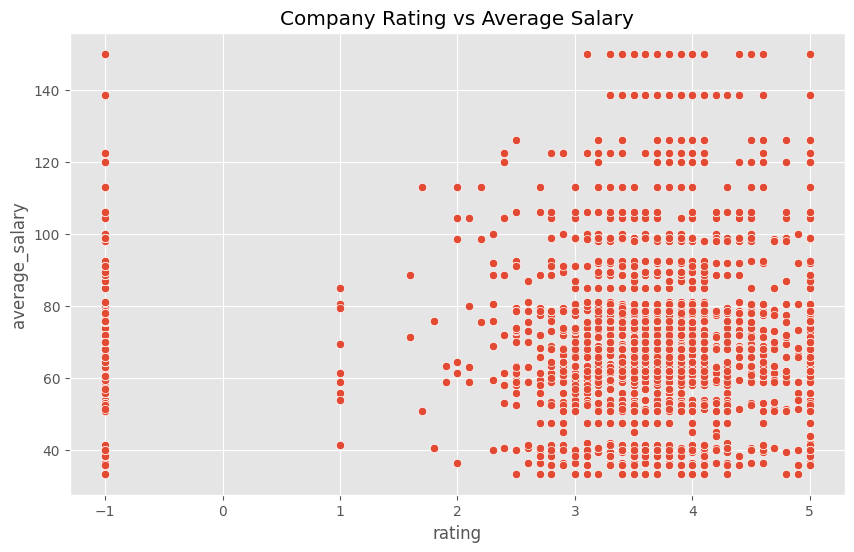

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='rating',
    y='average_salary',
    data=df
)

plt.title("Company Rating vs Average Salary")

plt.show()

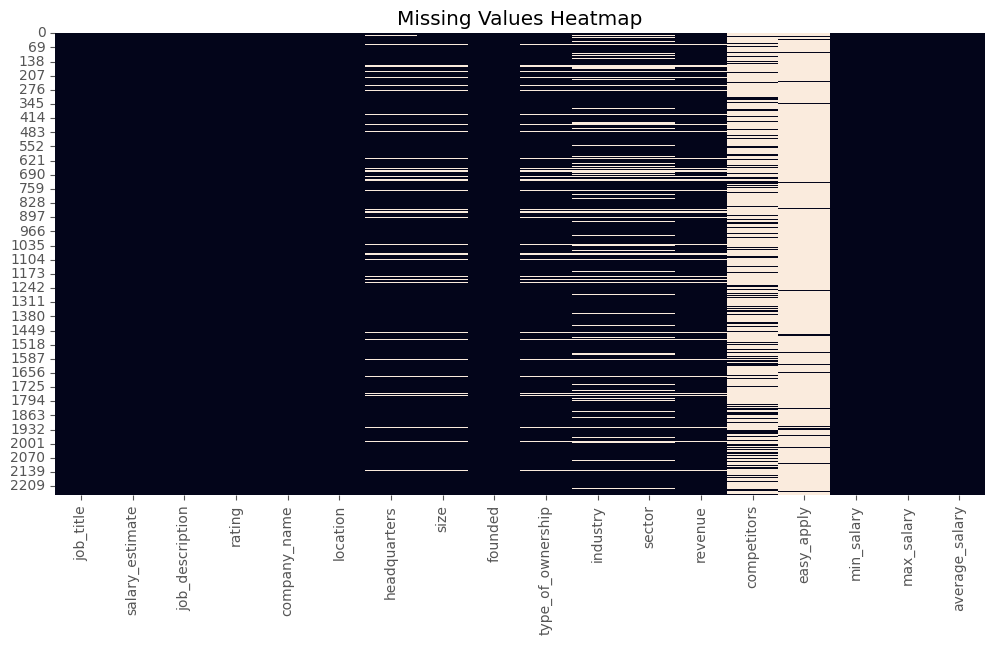

In [41]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [42]:
df.to_csv("../data/cleaned_featured_jobs.csv", index=False)